In [ ]:
###
    # This code plot the constrained sensivity of permafrost area under climate change, derived from seasonal soil temperature sensitivity.
    # Same with Figure 1, but using classic regression emergent constraint.
    # Output: Figure S14.
###

In [1]:
import scipy.stats as stats
import scipy as sp
import numpy as np
import pandas as pd
from statsmodels.formula.api import ols
from scipy.stats import pearsonr
import string
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties

In [4]:
def group_mean(ss, fs, models, groups):
    ss = np.array(ss)
    fs = np.array(fs)

    group_ss = []
    group_fs = []
    group_names = []

    for gname, gmodels in groups.items():
        idx = [i for i, m in enumerate(models) if m in gmodels]
        if len(idx) == 0:
            continue

        group_ss.append(np.mean(ss[idx]))
        group_fs.append(np.mean(fs[idx]))
        group_names.append(gname)

    return np.array(group_ss), np.array(group_fs), group_names
# The function of plot

def plot_sensitivity(obsmean, obsstd, ss, fs, model,model_groups, i, j):
    
    # Convert input ss and fs to numpy arrays
    ss = np.array(ss, dtype=np.float64)
    fs = np.array(fs, dtype=np.float64).flatten()
    df = pd.DataFrame({'x': ss, 'y': fs})
    df = df.sort_values('x')

    # Perform linear regression
    ols_model = ols('y ~ x', data=df).fit()
    r, p_value = pearsonr(ss, fs)
    pred = ols_model.get_prediction(df)
    pred_summary = pred.summary_frame(alpha=0.05)
    
    xmean = np.mean(ss)
    xstd = np.std(ss)
    zmean = np.mean(fs)
    zstd = np.std(fs)
    
    # Confidence interval slope
    p, cov  = np.polyfit(ss, fs, 1, cov=True)           # Fit a first-degree polynomial using least squares; cov is the covariance matrix
    #print ('p ',p)
    #print ('cov ',cov)
    y_model = np.polyval(p, ss)                         # y-values corresponding to the fitted curve
    
    # Statistics
    n       = fs.size                                   # number of observations
    m       = p.size                                    # number of parameters
    dof     = n - m                                     # degrees of freedom
    t       = stats.t.ppf(0.95, n - m)                  # used for CI and PI bands for the linear fit
    
    # Estimates of Error in Data/Model
    resid    = fs - y_model                           
    chi2     = np.sum((resid/y_model)**2)               # chi-squared; estimates error in data
    chi2_red = chi2/(dof)                               # reduced chi-squared; measures goodness of fit
    s_err    = np.sqrt(np.sum(resid**2)/(dof))          # standard deviation of the error
    # Sum of squared deviations between estimated and actual values. Standard error indicates the relative deviation of actual values from the estimated values; used to assess the representativeness of the regression model.

    # Inference with confidence interval of the curve
    nbboot  = 10000                                     # number of bootstrap
    sigma   = s_err                                     # Standard deviation of the error
    yinfer  = np.zeros(nbboot)
    bootindex = np.random.randint
    for ij in range(nbboot):
        idx = bootindex(0, n-1, n)                      # random indices with replacement
        # Make coeffs for polynomials
        pc = sp.polyfit(ss[idx], fs[idx], 1)            # fit a second-degree polynomial using the 18 bootstrap samples (with replacement)
        yinfer[ij]  = pc[0]*obsmean + pc[1] + sigma*np.random.randn()  # prediction inference: evaluate at the mean observation and add random error scaled by the standard error

    # Confidence interval of yinfer (inferred values)
    zmean_EC = np.mean(yinfer)
    zstd_EC = np.std(yinfer)

    print('zmean_EC = ' + str(round(zmean_EC, 4)))
    print('zstd_EC = ' + str(round(zstd_EC, 4)))
    print('RCM ' +str(round(((zmean_EC-zmean)/zmean)*100,2))+'%')
    print('RRV ' +str(round((1-zstd_EC*zstd_EC/zstd/zstd)*100,2))+'%')

    tem = ["1.5°C", "2°C", "3°C"]
    row_title = ["1.6m", "2.4m", "3.2m"]
    letters = list(string.ascii_lowercase) 
    
    ax = axs[i, j]
    
    # Set labels for subplots
    ax.text( -0.18, 1.04,  
            f"{letters[3*i+j]}",
            transform=ax.transAxes, 
            fontproperties=FontProperties(weight='bold', size=11),
            verticalalignment='bottom',
            color='black')
    if i == 2 and j == 1:
        x_labels = ["Seasonal sensitivity of soil temperature (°C/°C)"]
        ax.set_xlabel(x_labels[0], labelpad=12, fontsize=14)
    if i == 1 and j == 0:
        y_labels = ["Sensitivity of permafrost loss to global warming (%/°C)"]
        ax.set_ylabel(y_labels[0], labelpad=43, fontsize=14)
    if i == 0:
        ax.set_title(row_title[j], fontsize=12, c='black')

    if j == 0:
        ax.text(-0.27, 0.5, tem[i], va='center', ha='right', rotation='vertical', 
                   fontsize=12, transform=ax.transAxes)
        
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'X']
    colors = plt.cm.Set1(np.linspace(0, 1, len(fs)))  # Generate color list using colormap
    ax.plot(df['x'].values, pred_summary['mean'].values, color='blue', linewidth=2)
    ax.fill_between(df['x'], pred_summary['mean_ci_lower'], pred_summary['mean_ci_upper'], color='blue', alpha=0.2)
    # Plot scatter plot
    h = 0
    for s, f, color, model in zip(ss, fs, colors, model):
        ax.scatter(s, f, color=color, marker=markers[h % len(markers)],
                    s=38, alpha=0.76,edgecolors='black',linewidth=0.6,
                    zorder=3,label=model)
        h = h + 1

    if j == 0:
        ax.set_ylim(-105,0)
        ax.set_xlim(0.18,0.61)
        ax.xaxis.set_minor_locator(plt.MultipleLocator(0.02))
        ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))
        ax.yaxis.set_minor_locator(plt.MultipleLocator(4))
        ax.yaxis.set_major_locator(plt.MultipleLocator(20))
        ax.tick_params(axis='both', which='major', labelsize=11)
        ax.tick_params(axis='both', which='minor', length=2, color='black')
        ax.plot([np.max(ss) + 0.02, np.max(ss) + 0.02], [zmean - zstd, zmean + zstd], color='blue', linewidth=2)
        ax.scatter(np.max(ss) + 0.02, zmean, color='blue', s=30)
        ax.scatter(np.max(ss) + 0.035, zmean_EC, color='black', s=30)
        ax.plot([np.max(ss) + 0.035, np.max(ss) + 0.035], [zmean_EC - zstd_EC, zmean_EC + zstd_EC], color='black', linewidth=2)
    elif j == 1:
        ax.set_ylim(-57, -5)
        ax.set_xlim(0.13,0.44)
        ax.xaxis.set_minor_locator(plt.MultipleLocator(0.02))
        ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))
        ax.yaxis.set_minor_locator(plt.FixedLocator(np.arange(-57, -5, 2)))
        ax.yaxis.set_major_locator(plt.MultipleLocator(10))
        ax.tick_params(axis='both', which='major', labelsize=11)
        ax.tick_params(axis='both', which='minor', length=2, color='black')
        ax.set_yticks(np.arange(-60, -5, 10) + 5)
        ax.set_yticklabels([str(m) for m in range(-55, 0, 10)], color='black') 
        ax.plot([np.max(ss) + 0.02, np.max(ss) + 0.02], [zmean - zstd, zmean + zstd], color='blue', linewidth=2)
        ax.scatter(np.max(ss) + 0.02, zmean, color='blue', s=30)
        ax.scatter(np.max(ss) + 0.032, zmean_EC, color='black', s=30)
        ax.plot([np.max(ss) + 0.032, np.max(ss) + 0.032], [zmean_EC - zstd_EC, zmean_EC + zstd_EC], color='black', linewidth=2)
    else:
        ax.set_ylim(-47,-5)
        #ax.set_xlim(0.1,0.365)
        ax.set_xlim(0.1,0.352)
        ax.xaxis.set_minor_locator(plt.MultipleLocator(0.02))
        ax.xaxis.set_major_locator(plt.MultipleLocator(0.1))
        ax.yaxis.set_minor_locator(plt.FixedLocator(np.arange(-47, -5, 2)))
        ax.yaxis.set_major_locator(plt.MultipleLocator(10))
        ax.tick_params(axis='both', which='major', labelsize=11)
        ax.tick_params(axis='both', which='minor', length=2, color='black')
        ax.set_yticks(np.arange(-50, -5, 10) + 5)
        ax.set_yticklabels([str(m) for m in range(-45, 0, 10)], color='black') 
        ax.plot([np.max(ss) + 0.014, np.max(ss) + 0.014], [zmean - zstd, zmean + zstd], color='blue', linewidth=2)
        ax.scatter(np.max(ss) + 0.014, zmean, color='blue', s=30)
        ax.scatter(np.max(ss) + 0.024, zmean_EC, color='black', s=30)
        ax.plot([np.max(ss) + 0.024, np.max(ss) + 0.024], [zmean_EC - zstd_EC, zmean_EC + zstd_EC], color='black', linewidth=2)
    ylim = ax.get_ylim()
    ax.plot([obsmean, obsmean], [ylim[0], ylim[0] + 0.94 * (ylim[1] - ylim[0])], color='black', linewidth=1.5, linestyle='--')
    ax.text(obsmean, ylim[0] + 0.97 * (ylim[1] - ylim[0]), "obs", ha='center', va='center', fontsize=10)
    ax.fill_betweenx([ylim[0], ylim[0] + 0.94 * (ylim[1] - ylim[0])], obsmean - obsstd, obsmean + obsstd, color='gray', alpha=0.3)        
    ax.set_ylim(ylim[0], ylim[1])              # Set y-axis range from 0 to 12

    if i == 2 and j == 1:
        ax.legend(loc='upper center', bbox_to_anchor=(0.48, -0.31), edgecolor='lightgrey', shadow=False, ncol=5)
    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = ''                      # Do not display asterisks when the result is not statistically significant

    # Add correlation coefficient and statistical significance to the plot
    ax.text(0.04, 0.1,f"$R = {r:.2f}${significance}", ha='left', va='center', transform=ax.transAxes, fontsize=10)
    ax.grid(True, linestyle='--', linewidth=1, alpha=0.2)
    return fig

160cm
zmean_EC = -48.8437
zstd_EC = 15.3878
RCM 20.15%
RRV 48.13%
zmean_EC = -43.8673
zstd_EC = 10.7888
RCM 16.94%
RRV 50.42%
zmean_EC = -33.3019
zstd_EC = 5.3695
RCM 8.66%
RRV 38.74%
240cm
zmean_EC = -31.6565
zstd_EC = 6.3567
RCM 18.32%
RRV 46.96%
zmean_EC = -33.5504
zstd_EC = 7.2467
RCM 21.11%
RRV 49.95%
zmean_EC = -30.2442
zstd_EC = 5.3291
RCM 14.24%
RRV 43.63%
320cm
zmean_EC = -24.3568
zstd_EC = 4.9405
RCM 7.83%
RRV 57.55%
zmean_EC = -25.1866
zstd_EC = 5.5058
RCM 8.63%
RRV 59.19%
zmean_EC = -24.7369
zstd_EC = 4.8142
RCM 6.17%
RRV 52.71%


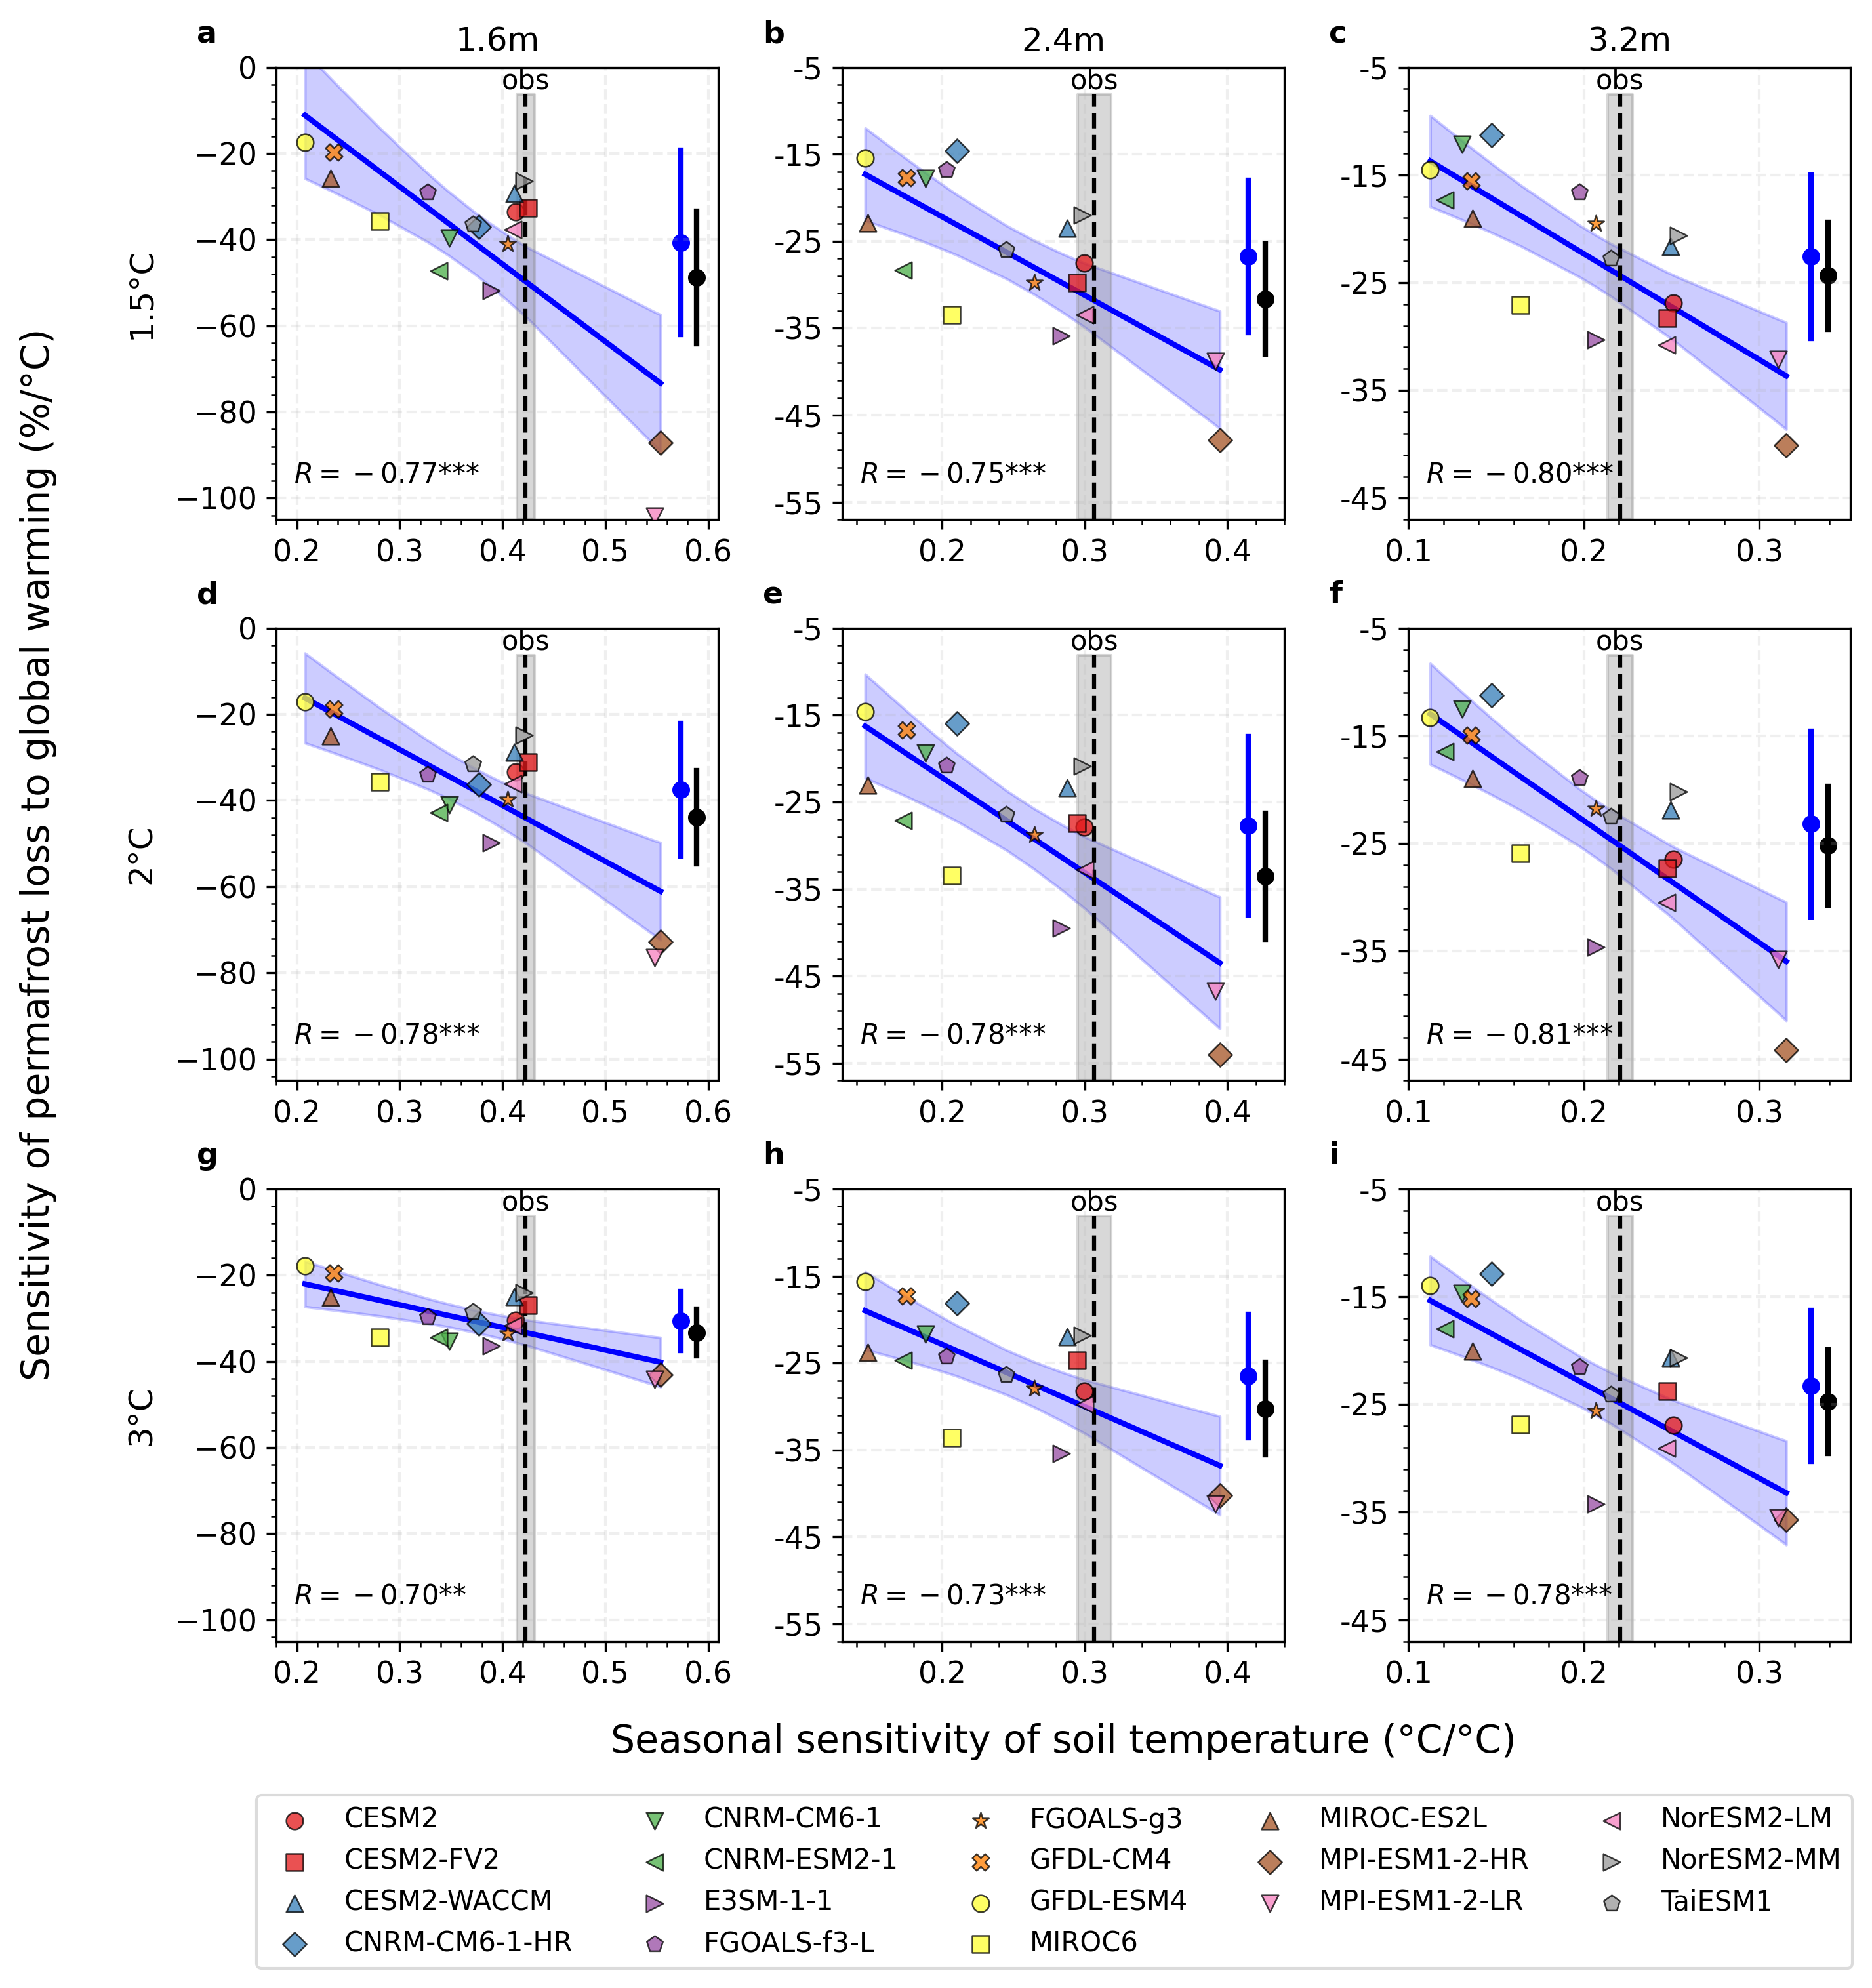

In [6]:
model_order = ["CESM2","CESM2-FV2","CESM2-WACCM","CNRM-CM6-1-HR","CNRM-CM6-1","CNRM-ESM2-1",
               "E3SM-1-1","FGOALS-f3-L","FGOALS-g3","GFDL-CM4","GFDL-ESM4","MIROC6",
               "MIROC-ES2L","MPI-ESM1-2-HR","MPI-ESM1-2-LR","NorESM2-LM","NorESM2-MM","TaiESM1"]
model_groups = {
    "CESM": ["CESM2","CESM2-FV2","CESM2-WACCM"],
    "CNRM": ["CNRM-CM6-1-HR","CNRM-CM6-1","CNRM-ESM2-1"],
    "FGOALS": ["FGOALS-f3-L","FGOALS-g3"],
    "GFDL": ["GFDL-CM4","GFDL-ESM4"],
    "MIROC": ["MIROC6","MIROC-ES2L"],
    "MPI": ["MPI-ESM1-2-HR","MPI-ESM1-2-LR"],
    "NorESM": ["NorESM2-LM","NorESM2-MM"],
    "E3SM": ["E3SM-1-1"],
    "TaiESM": ["TaiESM1"]
}
depths = ['160cm', '240cm', '320cm']

# Set up the plot
fig, axs = plt.subplots(3, 3, figsize=(10, 10), dpi=300)
fig.subplots_adjust(wspace=0.28, hspace=0.24)  # Adjust horizontal and vertical spacing

# Define excluded models as a set for faster lookup
excluded_models = {
    "KACE-1-0", "CanESM5", "CanESM5-CanOE", "IPSL-CM6A-LR"
    ,"CAS-ESM2-0","CMCC-CM2-SR5", "CMCC-ESM2"
}

# Function to read data from a file
def read_data_file(file_path):
    with open(file_path) as file:
        return [float(line.strip()) for line in file.readlines()]

# Process each depth
a = 0
for depth in depths:
    print(depth)
    # Read sensitivity data from CSV file
    file_path = "../Data/Permafrost_sensitivity/" + depth + "_permafrost_sensitivity_under_climate_change_ssp585.csv"
    pfarea_dt = pd.read_csv(file_path).set_index('model').loc[model_order]
    pfarea_dt3, pfarea_dt2, pfarea_dt15 = pfarea_dt['3'], pfarea_dt['2'], pfarea_dt['1.5']
    
    # Read temperature data (sorted by model order)
    Ts_path = f"../Data/Ts_seasonal_sensitivity/Ts"+depth+"_Ts02_all_station_avg_obs_18model.txt"
    Ts_dt = read_data_file(Ts_path)
    
    # Filter out excluded models
    midx = [model not in excluded_models for model in model_order]
    
    # Plot sensitivity for each depth
    for i, pfarea in enumerate([pfarea_dt15, pfarea_dt2, pfarea_dt3]):
        plot_sensitivity(Ts_dt[-2], Ts_dt[-1], 
                         Ts_dt[:-2], 
                         pfarea[midx], model_order,model_groups, i, a)
    a += 1

# Adjust layout and show plot
plt.subplots_adjust(left=0.15, right=0.95,bottom=0.15, top=0.95) 
plt.show()

In [ ]:
fig.savefig("../Figures/FigureS14.png", bbox_inches='tight',dpi=300)